Car Recommender System ด้วย Graph

ตัวอย่างสถานการณ์ มีผู้ใช้ 10 คน

```
Alice
Bob
Charlie
David
Emma
Frank
Grace
Henry
Ivy
Jack
```




และรถ 10 รุ่น

```
Toyota Yaris
Honda City
Toyota Corolla
Honda Civic
Mazda 3
Nissan Almera
Ford Ranger
Toyota Camry
Honda Accord
Mazda CX-5
```

รวมทั้งหมด

10 User + 10 Car = 20 Nodes

สมมติข้อมูลความชอบคือ

```
Alice   → Toyota Yaris
Alice   → Honda City
Alice   → Toyota Corolla

Bob     → Toyota Yaris
Bob     → Honda City
Bob     → Toyota Corolla
Bob     → Honda Civic

Charlie → Toyota Yaris
Charlie → Toyota Corolla
Charlie → Mazda 3

David   → Toyota Corolla
David   → Honda Civic
David   → Mazda 3
David   → Nissan Almera

Emma    → Honda Civic
Emma    → Mazda 3
Emma    → Nissan Almera

Frank   → Nissan Almera
Frank   → Ford Ranger
Frank   → Toyota Camry

Grace   → Ford Ranger
Grace   → Toyota Camry
Grace   → Honda Accord

Henry   → Toyota Camry
Henry   → Honda Accord
Henry   → Mazda CX-5

Ivy     → Honda Accord
Ivy     → Mazda CX-5
Ivy     → Toyota Yaris

Jack    → Mazda CX-5
Jack    → Toyota Yaris
Jack    → Honda City
```



เราจะสังเกตได้ว่า

Alice และ Bob ชอบรถเหมือนกันคือ

Toyota Yaris
Honda City
Toyota Corolla

แต่ Bob ยังชอบ Honda Civic

ดังนั้นระบบสามารถคิดง่าย ๆ ว่า

ถ้า Alice กับ Bob มีความชอบรถยนต์คล้ายกัน และ Bob ชอบ Honda Civic แต่ Alice ยังไม่ได้เลือก Honda Civic ระบบอาจแนะนำ Honda Civic ให้ Alice

การออกแบบ Graph
```
User
Alice
Bob
Charlie
David
Emma
Frank
Grace
Henry
Ivy
Jack
รวมทั้งหมด 10 User Nodes

Car
Toyota Yaris
Honda City
Toyota Corolla
Honda Civic
Mazda 3
Nissan Almera
Ford Ranger
Toyota Camry
Honda Accord
Mazda CX-5
รวมทั้งหมด 10 Car Nodes

Relationship คือ

LIKES

ดังนั้น

(User)-[:LIKES]->(Car)

เช่น

(Alice)-[:LIKES]->(Toyota Yaris)

(Alice)-[:LIKES]->(Honda City)

(Bob)-[:LIKES]->(Toyota Yaris)

(Bob)-[:LIKES]->(Honda Civic)
```

สร้างด้วย Python บน Google Colab

In [ ]:
!pip -q install networkx

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:
G = nx.Graph()

In [ ]:
users = [
    "Alice",
    "Bob",
    "Charlie",
    "David",
    "Emma",
    "Frank",
    "Grace",
    "Henry",
    "Ivy",
    "Jack"
]

for user in users:

    G.add_node(
        user,
        node_type="user"
    )

In [ ]:
cars = [
    "Toyota Yaris",
    "Honda City",
    "Toyota Corolla",
    "Honda Civic",
    "Mazda 3",
    "Nissan Almera",
    "Ford Ranger",
    "Toyota Camry",
    "Honda Accord",
    "Mazda CX-5"
]

for car in cars:

    G.add_node(
        car,
        node_type="car"
    )

In [ ]:
likes = [

    # Alice
    ("Alice", "Toyota Yaris"),
    ("Alice", "Honda City"),
    ("Alice", "Toyota Corolla"),

    # Bob
    ("Bob", "Toyota Yaris"),
    ("Bob", "Honda City"),
    ("Bob", "Toyota Corolla"),
    ("Bob", "Honda Civic"),

    # Charlie
    ("Charlie", "Toyota Yaris"),
    ("Charlie", "Toyota Corolla"),
    ("Charlie", "Mazda 3"),

    # David
    ("David", "Toyota Corolla"),
    ("David", "Honda Civic"),
    ("David", "Mazda 3"),
    ("David", "Nissan Almera"),

    # Emma
    ("Emma", "Honda Civic"),
    ("Emma", "Mazda 3"),
    ("Emma", "Nissan Almera"),

    # Frank
    ("Frank", "Nissan Almera"),
    ("Frank", "Ford Ranger"),
    ("Frank", "Toyota Camry"),

    # Grace
    ("Grace", "Ford Ranger"),
    ("Grace", "Toyota Camry"),
    ("Grace", "Honda Accord"),

    # Henry
    ("Henry", "Toyota Camry"),
    ("Henry", "Honda Accord"),
    ("Henry", "Mazda CX-5"),

    # Ivy
    ("Ivy", "Honda Accord"),
    ("Ivy", "Mazda CX-5"),
    ("Ivy", "Toyota Yaris"),

    # Jack
    ("Jack", "Mazda CX-5"),
    ("Jack", "Toyota Yaris"),
    ("Jack", "Honda City")

]

เพิ่มเข้า Graph

In [ ]:
G.add_edges_from(likes)

วาด Graph

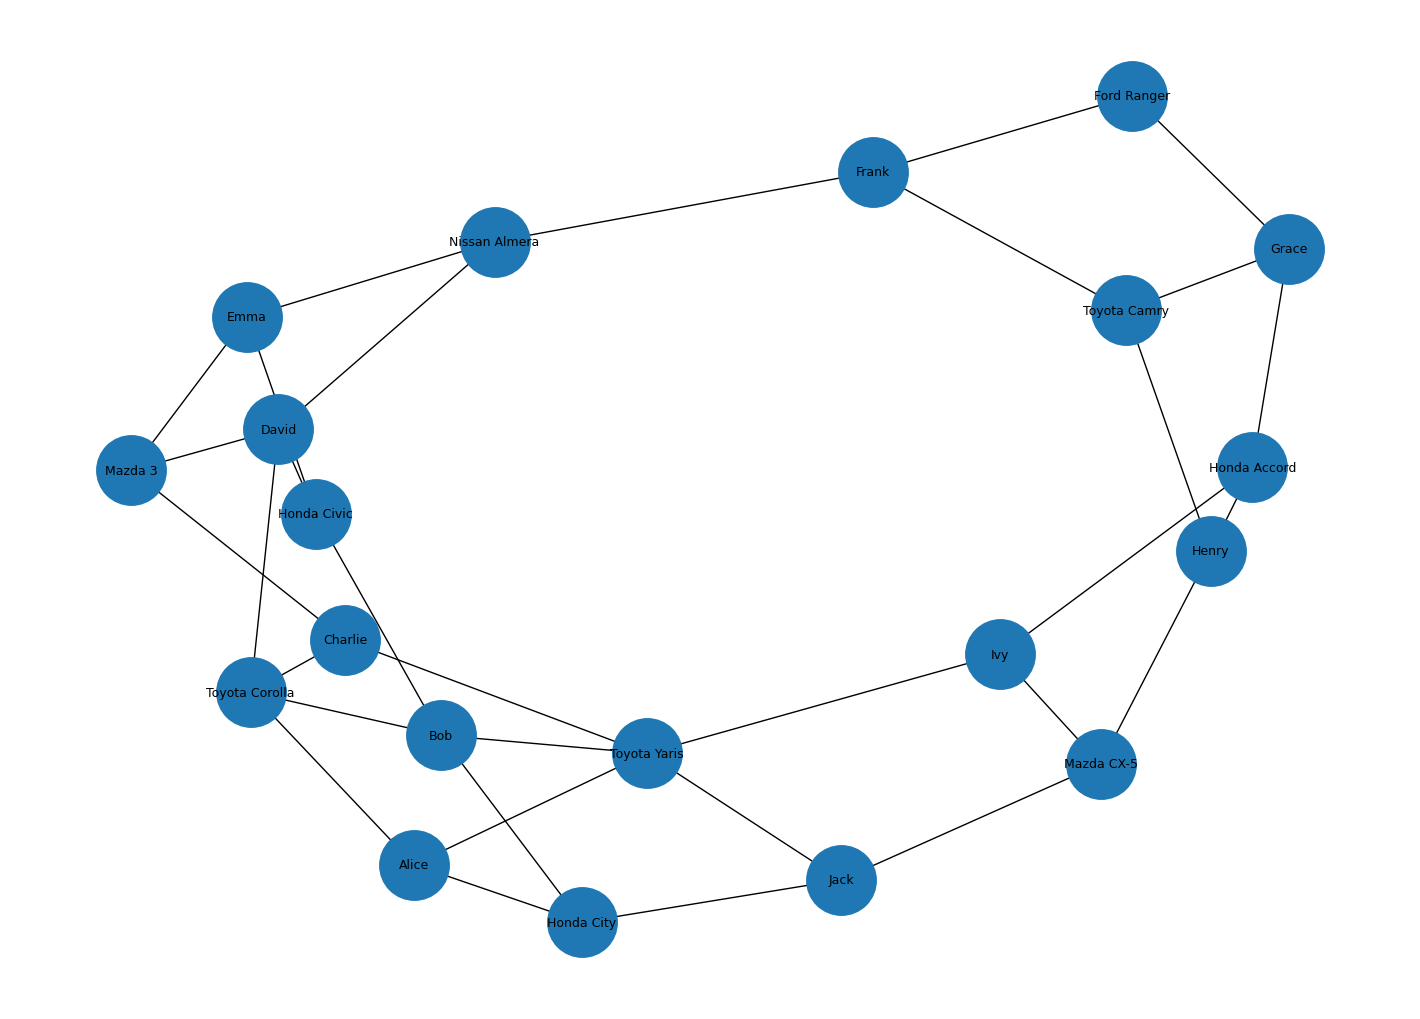

In [ ]:
plt.figure(figsize=(14, 10))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    font_size=9
)

plt.show()

คำถามที่ 1 Alice ชอบรถยนต์รุ่นอะไรบ้าง?

In [ ]:
alice_cars = list(
    G.neighbors("Alice")
)

print(alice_cars)

['Toyota Yaris', 'Honda City', 'Toyota Corolla']


อธิบาย

G.neighbors("Alice")

ใช้หา Node ที่เชื่อมต่อกับ Alice

ดังนั้นรถยนต์ที่เป็น Neighbor ของ Alice ก็คือรถยนต์ที่ Alice ชอบ

คำถามที่ 2 หา User ที่ชอบรถเหมือน Alice

In [ ]:
for car in G.neighbors("Alice"):

    print("Car:", car)

    for user in G.neighbors(car):

        if user != "Alice":
            print("  Similar user:", user)

Car: Toyota Yaris
  Similar user: Bob
  Similar user: Charlie
  Similar user: Ivy
  Similar user: Jack
Car: Honda City
  Similar user: Bob
  Similar user: Jack
Car: Toyota Corolla
  Similar user: Bob
  Similar user: Charlie
  Similar user: David


จะเห็นว่า
```
Bob ชอบรถเหมือน Alice จำนวน 3 รุ่น

Charlie ชอบเหมือน Alice จำนวน 2 รุ่น

Ivy ชอบรถเหมือน Alice จำนวน 1 รุ่น

Jack ชอบรถเหมือน Alice จำนวน 2 รุ่น

David ชอบรถเหมือน Alice จำนวน 1 รุ่น

ดังนั้น Bob มีความชอบใกล้เคียง Alice มากกว่า
```

สร้าง Recommendation แบบง่าย
```
แนวคิดคือ
Alice
 ↓
รถยนต์ที่ Alice ชอบ
 ↓
User ที่ชอบรถยนต์เหมือนกัน
 ↓
รถยนต์อื่นที่ User เหล่านั้นชอบ
 ↓
แนะนำให้ Alice
```

ตัวอย่างเช่น
```
Alice
 ↓
Toyota Yaris
 ↓
Bob / Charlie
 ↓
Honda Civic
 ↓
แนะนำ Honda Civic ให้ Alice
```

In [ ]:
target_user = "Alice"

recommendations = Counter()

# รถที่ Alice ชอบแล้ว
liked_cars = set(
    G.neighbors(target_user)
)

# ดูรถแต่ละคันที่ Alice ชอบ
for car in liked_cars:

    # หา User ที่ชอบรถคันเดียวกัน
    for similar_user in G.neighbors(car):

        if similar_user == target_user:
            continue

        # ดูรถอื่นที่ User คนนั้นชอบ
        for other_car in G.neighbors(similar_user):

            # Alice ยังไม่ได้ชอบรถคันนี้
            if other_car not in liked_cars:

                recommendations[other_car] += 1


print(recommendations)

Counter({'Honda Civic': 4, 'Mazda 3': 3, 'Mazda CX-5': 3, 'Honda Accord': 1, 'Nissan Almera': 1})


อธิบาย

Honda Civic ถูกพบจาก User ที่มีความสัมพันธ์กับ Alice จำนวน 4 ครั้ง
```
เนื่องจาก

Alice
 ↓
Toyota Yaris
 ↓
Bob
 ↓
Honda Civic

และ

Alice
 ↓
Honda City
 ↓
Bob
 ↓
Honda Civic

และ

Alice
 ↓
Toyota Corolla
 ↓
Bob
 ↓
Honda Civic

และ

Alice
 ↓
Toyota Corolla
 ↓
David
 ↓
Honda Civic
```
ดังนั้น Honda Civic ได้คะแนน

Score = 4

ระบบจึงสามารถแนะนำ Honda Civic ให้ Alice ได้

นำไปสร้างเป็นฟังก์ชัน

In [ ]:
def recommend_cars(G, target_user):
    recommendations = Counter()
    liked_cars = set(G.neighbors(target_user))

    # 1. วนลูปดูรถทุกคันที่ target_user ชอบ
    for car in liked_cars:

        # 2. หา User คนอื่นที่ชอบรถคันเดียวกัน
        for similar_user in G.neighbors(car):
            if similar_user == target_user:
                continue

            # 3. ดูว่า User คนนั้นชอบรถคันไหนอีกบ้างที่ target_user ยังไม่เคยชอบ
            for other_car in G.neighbors(similar_user):
                if other_car not in liked_cars:
                    recommendations[other_car] += 1

    return recommendations.most_common()

In [ ]:
#เรียกใช้งาน
result_alice = recommend_cars(G, "Alice")
print(result_alice)

[('Honda Civic', 4), ('Mazda 3', 3), ('Mazda CX-5', 3), ('Honda Accord', 1), ('Nissan Almera', 1)]


In [ ]:
#เรียกใช้งานให้ Charlie
result_charlie = recommend_cars(G, "Charlie")
print(result_charlie)

[('Honda City', 5), ('Honda Civic', 5), ('Nissan Almera', 3), ('Mazda CX-5', 2), ('Honda Accord', 1)]


In [ ]:
#เรียกใช้งานให้ David
result_david = recommend_cars(G, "David")
print(result_david)

[('Toyota Yaris', 5), ('Honda City', 3), ('Ford Ranger', 1), ('Toyota Camry', 1)]


In [ ]:
#ดูว่ามีรถอะไรที่ Alice ชอบบ้าง
alice_cars = list(
    G.neighbors("Alice")
)

print(alice_cars)

['Toyota Yaris', 'Honda City', 'Toyota Corolla']


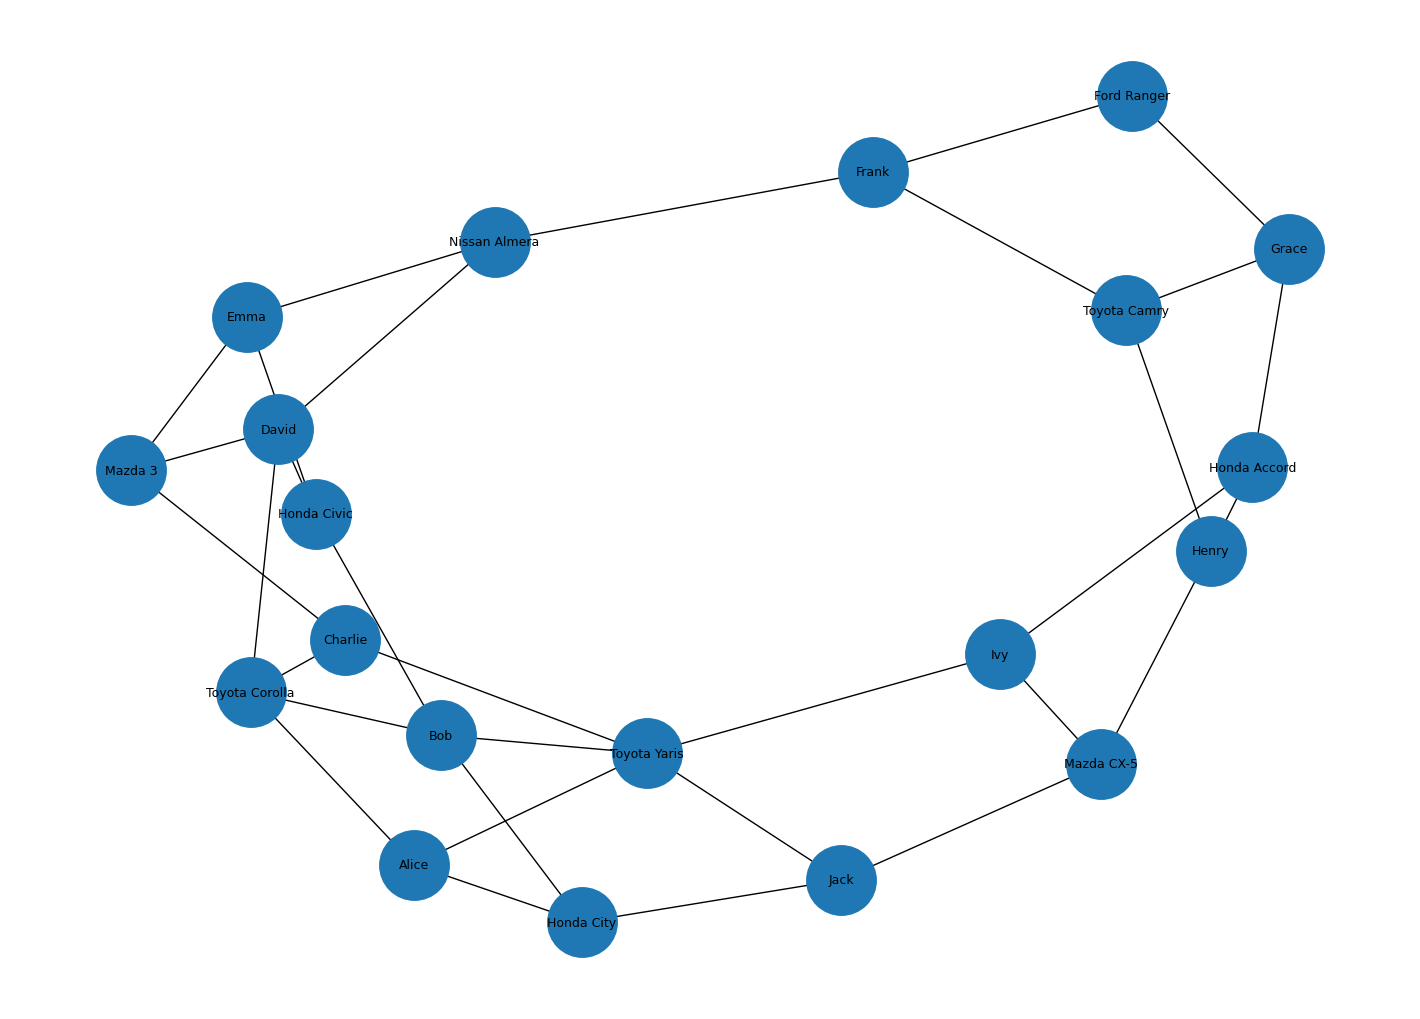

Recommendations for Alice
Honda Civic Score = 4
Mazda 3 Score = 3
Mazda CX-5 Score = 3
Honda Accord Score = 1
Nissan Almera Score = 1


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter


# ==================================
# 1. Create Graph
# ==================================

G = nx.Graph()


# ==================================
# 2. Add Users (10 Nodes)
# ==================================

users = [
    "Alice",
    "Bob",
    "Charlie",
    "David",
    "Emma",
    "Frank",
    "Grace",
    "Henry",
    "Ivy",
    "Jack"
]

for user in users:

    G.add_node(
        user,
        node_type="user"
    )


# ==================================
# 3. Add Cars (10 Nodes)
# ==================================

cars = [
    "Toyota Yaris",
    "Honda City",
    "Toyota Corolla",
    "Honda Civic",
    "Mazda 3",
    "Nissan Almera",
    "Ford Ranger",
    "Toyota Camry",
    "Honda Accord",
    "Mazda CX-5"
]

for car in cars:

    G.add_node(
        car,
        node_type="car"
    )


# ==================================
# 4. User-Car Relationships
# ==================================

likes = [

    # Alice
    ("Alice", "Toyota Yaris"),
    ("Alice", "Honda City"),
    ("Alice", "Toyota Corolla"),

    # Bob
    ("Bob", "Toyota Yaris"),
    ("Bob", "Honda City"),
    ("Bob", "Toyota Corolla"),
    ("Bob", "Honda Civic"),

    # Charlie
    ("Charlie", "Toyota Yaris"),
    ("Charlie", "Toyota Corolla"),
    ("Charlie", "Mazda 3"),

    # David
    ("David", "Toyota Corolla"),
    ("David", "Honda Civic"),
    ("David", "Mazda 3"),
    ("David", "Nissan Almera"),

    # Emma
    ("Emma", "Honda Civic"),
    ("Emma", "Mazda 3"),
    ("Emma", "Nissan Almera"),

    # Frank
    ("Frank", "Nissan Almera"),
    ("Frank", "Ford Ranger"),
    ("Frank", "Toyota Camry"),

    # Grace
    ("Grace", "Ford Ranger"),
    ("Grace", "Toyota Camry"),
    ("Grace", "Honda Accord"),

    # Henry
    ("Henry", "Toyota Camry"),
    ("Henry", "Honda Accord"),
    ("Henry", "Mazda CX-5"),

    # Ivy
    ("Ivy", "Honda Accord"),
    ("Ivy", "Mazda CX-5"),
    ("Ivy", "Toyota Yaris"),

    # Jack
    ("Jack", "Mazda CX-5"),
    ("Jack", "Toyota Yaris"),
    ("Jack", "Honda City")

]


G.add_edges_from(likes)


# ==================================
# 5. Draw Graph
# ==================================

plt.figure(
    figsize=(14, 10)
)


pos = nx.spring_layout(
    G,
    seed=42
)


nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    font_size=9
)


plt.show()


# ==================================
# 6. Recommendation Function
# ==================================

def recommend_cars(
    G,
    target_user
):

    recommendations = Counter()

    liked_cars = set(
        G.neighbors(
            target_user
        )
    )

    for car in liked_cars:

        for similar_user in G.neighbors(car):

            if similar_user == target_user:
                continue

            for other_car in G.neighbors(
                similar_user
            ):

                if other_car not in liked_cars:

                    recommendations[
                        other_car
                    ] += 1

    return recommendations.most_common()


# ==================================
# 7. Recommend for Target User
# ==================================

target_user = "Alice"

result = recommend_cars(
    G,
    target_user
)


print(
    "Recommendations for",
    target_user
)


for car, score in result:

    print(
        car,
        "Score =",
        score
    )